In [122]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

In [123]:
filename='Base No Clientes Mayo 26 _ Entregada a la red 01052026.csv'
df_base=cargar_archivo_csv(spark,filename,';',True)

# filename='BASE_CEL_TARGET_20260501.csv'
# df_score=cargar_archivo_csv(spark,filename,';',True)


In [124]:
from pyspark.sql import functions as F

exprs = [
    F.count(F.when(F.col(c).isNotNull(), c)).alias(c)
    for c in df_base.columns
]

df_counts = df_base.agg(*exprs).collect()[0].asDict()

cols_con_data = [c for c, v in df_counts.items() if v > 0]

df_base = df_base.select(cols_con_data)

In [125]:
df_base=df_base.withColumnRenamed('DNI','NUMERO_DOCUMENTO')
df_base=df_base.withColumnRenamed('CET','cl_telf1')
df_base=df_base.withColumnRenamed('CEL1','cl_telf2')

In [ ]:
df_base=df_base.withColumnRenamed('COLOR','color')
df_base=df_base.withColumnRenamed('REGION_COMERCIAL','Region_comercial')
df_base=df_base.withColumnRenamed('AGENCIA_COMERCIAL','Agencia_comercial')
df_base=df_base.withColumnRenamed('CAMPAÑA','campania')
df_base=df_base.withColumnRenamed('TIPO_CLIENTE_COMERCIAL','tipo_cliente_riegos')
df_base=df_base.withColumnRenamed('CLIENTE','NOMBRES')
df_base=df_base.withColumnRenamed('OFERTA_COMPETITIVA','PEER')
df_base=df_base.withColumnRenamed('PROP','PROPENSION')
# df_base=df_base.withColumnRenamed('DIRECCION','Ubicacion')
df_base=df_base.withColumnRenamed('CAPACIDAD DE PAGO','CAPACIDAD_MAX')
df_base=df_base.withColumnRenamed('OFERTA_NETA','OFERTA_MAX')

    

In [31]:
print([row['CAPACIDAD DE PAGO' ] for row in df_base.select('CAPACIDAD DE PAGO').distinct().collect()])
# print([row['PROP' ] for row in df_base.select('PROP').distinct().collect()])


['435.107', '987.077', '1021.52', '1127.36', '553.135', '877.965', '910.868', '511.691', '908.584', '1193.83', '817.308', '536.726', '609.244', '428.062', '553.483', '400.886', '422.96', '926.935', '1284.55', '426.936', '568.231', '488.218', '660.953', '843.176', '953.048', '875.881', '1118.75', '1168.28', '650.927', '743.398', '544.411', '847.03', '615.432', '1078.41', '1100.05', '607.272', '650.887', '863.482', '844.08', '542.953', '1166.96', '374.035', '717.865', '579.226', '900.372', '1469.25', '1488.14', '943.668', '646.102', '650.886', '685.333', '432.336', '824.826', '202.256', '329.111', '566.308', '976.927', '1321.4', '889.518', '644.853', '680.423', '793.578', '155.13', '1186.7', '1149.04', '1190.33', '347.734', '1572.15', '840.112', '848.152', '618.15', '1848.68', '1062.65', '2305.9', '174.718', '390.453', '1071.48', '3796.16', '206.43', '1146.85', '634.26', '869.892', '1431.88', '921.564', '401.381', '216.646', '621.741', '963.408', '460.825', '952.228', '564.98', '893.971'

In [127]:
df_base=df_base.drop('TASA_MIN', 'VARIACION_TASA_CAMPAÑA_ANTERIOR', 'VARIA_TASA', 'FLG_CET_6M', 'VARIA_OFER_CAMP_ANT', 'INGRESO')

cols_prueba = set(df_base.columns)

cols_formato = set(
    """cl_id, TIPO_DOI, NUMERO_DOCUMENTO, NOMBRES, APELLIDO_PATERNO, APELLIDO_MATERNO, SUCURSAL, TIENDA, DEPARTAMENTO, PROVINCIA, DISTRITO, FEC_NACIMIENTO, OFERTA_MAX, OFERTA_REEN, Tipo_verificacion, GRUPO_RIESGO, proveedor, lote, estado, Tasa_1, Tasa_2, Tasa_3, Tasa_4, Tasa_5, Tasa_6, Tasa_7, segmento, Campana, PLAZO, TEM, PROPENSION_IC, Desgravamen, CUOTA, Edad, Oferta_12M, Tasa_12M, Desgravamen_12M, CUOTA_12M, Oferta_18M, Tasa_18M, Desgravamen_18M, CUOTA_18M, Oferta_24M, Tasa_24M, Desgravamen_24M, CUOTA_24M, Oferta_36M, Tasa_36M, Desgravamen_36M, CUOTA_36M, Validador_Telefono, Prioridad, Nombre_prioridad, Deuda_1, Entidad_1, Deuda_2, Entidad_2, Deuda_3, Entidad_3, sucursal_comercial, Agencia_comercial, Region_comercial, Ubicacion, OfertaMaximaSinSeguro, color, color_final, PROPENSION, OFERTA_FINAL, GARANTIA, Oferta_Minima_Paperless, RANGO_OFERTA, RANGO_SUELDO, CAPACIDAD_MAX, PEER, PROP_COMER, TIPO_GEST, CLIENTE_NUEVO, GRUPO_TASA, NUEVOS_3M, NUEVOS_6M, NUEVOS_9M, NUEVOS_12M, NUEVOS_4M, GRUPO_MONTO, TASA_VS_MONTO, USUARIO, incremento_monto_riesgos, FLG_DEUDA_PLUS, tipo_cliente_riegos, USER_V3, LEAD_CALIDAD, SEGMENTO_USER, RANGO_EDAD, RANGO_OFERTA2, PERIODO, RETIRO_GEST, MEJOR_TIPIFICACION, STATUS, FECHA_SOL, BASE, RESULTADO, NUM_ENRIQUECIDO, TIPO_CONTACTO, Q_VENTAS, LOCALIDAD, DESEMBOLSADO, MONTO_DESEMBOLSADO, SBI, CRUCE, PREST_PREVIO, ID_CLIENTE, RANGO_EDAD2, Fecha_Envio, TIPO_BD, COD_BD, NOMB_BD, MES_GESTION, TIPO_CLIENTE, GRUPO_TASA_REENGANCHE, SALDO_DIFERENCIAL_REENG, FLAG_REENG, RETIRO_DESEMBOLSO, FRESCURA, flag_deuda_v_oferta, MGNEG, PERFIL_RO, TIPO_BASE, cl_telf1, cl_telf2, cl_telf3, cl_telf4, cl_telf5, cl_telf6, cl_telf7, cl_telf8, cl_telf9, cl_telf10, cl_movil, cl_celular, cl_telefono, cl_turno, cl_gestor, cl_asesor, cl_accion, cl_gestion, cl_estado, cl_fecha_gestion, cl_hora_gestion, cl_hits, cl_fecha_llamar, cl_prioridad, cl_orden, cl_predictivo, cl_tiempo, cl_base, cl_mes, cl_carga, id_carga, cl_area, fecha_alimentacion, cl_base_ant, cl_accion_ant, cl_fecha_ant, campania, PROMOCION, PROMOCION2, nombre_base, NumEntidades, p_banco, PERFIL_GLOBAL, FLG_AAHH, SCORE_TELEFONO, PILOTO_PLAZAS, INTENSIDAD_MAX"""
    .replace("\n", "")
    .split(",")
)

# limpiar espacios
cols_formato = set(col.strip() for col in cols_formato)

# comparación
solo_en_prueba = cols_prueba - cols_formato

print("Solo en df_base:", solo_en_prueba)
print(cols_formato)

Solo en df_base: set()
{'CRUCE', 'cl_celular', 'cl_fecha_ant', 'Nombre_prioridad', 'NUEVOS_9M', 'campania', 'LOCALIDAD', 'Entidad_3', 'incremento_monto_riesgos', 'cl_fecha_gestion', 'cl_mes', 'Tipo_verificacion', 'GRUPO_TASA_REENGANCHE', 'ID_CLIENTE', 'Tasa_2', 'RANGO_OFERTA', 'GRUPO_TASA', 'GRUPO_MONTO', 'SBI', 'Oferta_Minima_Paperless', 'Tasa_4', 'PROPENSION', 'color_final', 'INTENSIDAD_MAX', 'Deuda_2', 'FECHA_SOL', 'Oferta_12M', 'BASE', 'PROMOCION2', 'segmento', 'PILOTO_PLAZAS', 'NUEVOS_3M', 'estado', 'FLAG_REENG', 'cl_hits', 'RANGO_SUELDO', 'cl_accion_ant', 'TIENDA', 'RANGO_EDAD', 'TEM', 'CLIENTE_NUEVO', 'Oferta_18M', 'fecha_alimentacion', 'Fecha_Envio', 'Tasa_7', 'cl_predictivo', 'cl_id', 'MES_GESTION', 'OFERTA_FINAL', 'FRESCURA', 'Deuda_1', 'FEC_NACIMIENTO', 'PERFIL_RO', 'DEPARTAMENTO', 'PERIODO', 'MONTO_DESEMBOLSADO', 'cl_tiempo', 'cl_telf6', 'CUOTA_18M', 'cl_asesor', 'flag_deuda_v_oferta', 'APELLIDO_MATERNO', 'cl_area', 'Desgravamen_24M', 'PERFIL_GLOBAL', 'GARANTIA', 'cl_hora_g

In [128]:

df_base = df_base.withColumn("TIENDA", F.col("Agencia_comercial"))
# df_base = df_base.withColumn("SUCURSAL", F.col("Agencia_comercial"))
df_base = df_base.withColumn("lote", F.lit("BD-Target -ASM"))
df_base = df_base.withColumn("cl_base", F.lit("Mayo 2026"))
df_base = df_base.withColumn("cl_carga", F.lit("2026-05-03"))
df_base = df_base.withColumn("cl_estado", F.lit("1"))
df_base = df_base.withColumn("estado", F.lit("ACTIVO"))
df_base = df_base.withColumn("nombre_base", F.lit("2026-05-03"))


In [ ]:
print(df_base.count())

2172
2172


In [129]:
filename='lista_alfin_01.csv'
df_list_01=cargar_archivo_csv(spark,filename,';',True)

df_list_01=df_list_01.withColumnRenamed('dni','NUMERO_DOCUMENTO')

df_list_01 = df_list_01.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)

df_base= df_base.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)


In [130]:
df_list_01=df_list_01.withColumnRenamed('dni','NUMERO_DOCUMENTO')
df_list_01=df_list_01.withColumnRenamed('tasa_1','Tasa_1')
df_list_01=df_list_01.withColumnRenamed('tasa_2','Tasa_2')
df_list_01=df_list_01.withColumnRenamed('tasa_3','Tasa_3')
df_list_01=df_list_01.withColumnRenamed('tasa_4','Tasa_4')
df_list_01=df_list_01.withColumnRenamed('tasa_5','Tasa_5')
df_list_01=df_list_01.withColumnRenamed('tasa_6','Tasa_6')
df_list_01=df_list_01.withColumnRenamed('tasa_7','Tasa_7')
df_list_01=df_list_01.withColumnRenamed('oferta_max','OFERTA_MAX')
df_list_01=df_list_01.withColumnRenamed('user_v3','codigo')

df_list_01 = df_list_01.withColumn(
    "USER_V3",
    F.when(F.col("codigo") == '7', "7. Peers")
    .when(F.col("codigo") == '11', "11. Dependiente Banca")
    .when(F.col("codigo") == '3', "3. MES + PLD Peers")
    .when(F.col("codigo") == '8', "8. Tarjetero Cash")
    .when(F.col("codigo") == '5', "5. MES A")
    .when(F.col("codigo") == '6', "6. MES B")
    .when(F.col("codigo") == '9', "9. Dependiente BN")
    .when(F.col("codigo") == '1', "1. sunedu & sunarp A")
    .when(F.col("codigo") == '10', "10. Dependiente + Convenios")
    .when(F.col("codigo") == '4', "4. MES + PLD No Peers")
    .when(F.col("codigo") == '12', "12. Independiente A")
    .when(F.col("codigo") == '13', "13. No dependiente + Convenios")
    .when(F.col("codigo") == '14', "14. Otros Bancarizados")
    .when(F.col("codigo") == '2', "2. sunedu & sunarp B")
    .otherwise("Sin clasificar")
)
df_list_01=df_list_01.withColumnRenamed('grupo_tasa','codigo1')
df_list_01 = df_list_01.withColumn(
    "GRUPO_TASA",
    F.when(F.col("codigo1") == '0', "Sin información")
    .when(F.col("codigo1") == '1', "Menor tasa")
    .when(F.col("codigo1") == '2', "Mayor tasa")
    .when(F.col("codigo1") == '3', "Mantiene tasa")
    .otherwise("Sin clasificar")
)

df_list_01=df_list_01.withColumnRenamed('TIPO_BASE','codigo2')
df_list_01 = df_list_01.withColumn(
    "TIPO_BASE",
    F.when(F.col("codigo2") == '1', "Saldo Competidor")
    .when(F.col("codigo2") == '2', "Regular")
    .when(F.col("codigo2") == '3', "Blacklist")
    .otherwise("No Aplica")
)

df_list_01=df_list_01.withColumnRenamed('perfil_ro','codigo3')
df_list_01 = df_list_01.withColumn(
    "PERFIL_RO",
    F.when(F.col("codigo3") == '1', "Aceptante I")
    .when(F.col("codigo3") == '2', "Aceptante II")
    .when(F.col("codigo3") == '3', "Dispuesto I")
    .when(F.col("codigo3") == '4', "Dispuesto II")
    .when(F.col("codigo3") == '5', "Dispuesto III")
    .when(F.col("codigo3") == '6', "Resistente I")
    .when(F.col("codigo3") == '7', "Resistente II")
    .when(F.col("codigo3") == '8', "Inconforme I")
    .when(F.col("codigo3") == '9', "Inconforme II")
    .otherwise("No Aplica")
)


In [76]:
print([row['grupo_tasa' ] for row in df_list_01.select('grupo_tasa').distinct().collect()])


['0', '1', '2']


In [92]:
print(df_list_01.columns)
print(df_base.columns)


['NUMERO_DOCUMENTO', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'OFERTA_MAX', 'plazo', 'CAPACIDAD_PAGO_MEN', 'campaña_grupo', 'color_id', 'usuario', 'RANGO_DEUDA', 'NumEntidades', 'fresco', 'codigo', 'deuda_entidades', 'perfil_ro', 'Mgneg', 'AUTORIZACION_DATOS', 'MARCA_PD', 'flag_deuda_v_oferta', 'codigo1', 'PERFIL_ESPECIAL', 'codigo2', 'Tasa_1_SS', 'Tasa_2_SS', 'Tasa_3_SS', 'Tasa_4_SS', 'Tasa_5_SS', 'Tasa_6_SS', 'Tasa_7_SS', 'oferta_max_SS', 'TASA_MIN_DESCUENTO', 'PROPENSION', 'FEN', 'USER_V3', 'GRUPO_TASA', 'TIPO_BASE']
['PROPENSION', 'USUARIO', 'PEER', 'MGNEG', 'NUMERO_DOCUMENTO', 'NOMBRES', 'OFERTA_MAX', 'Agencia_comercial', 'cl_telf1', 'cl_telf2', 'PLAZO', 'campania', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'Region_comercial', 'TIPO_CLIENTE', 'tipo_cliente_riegos', 'FRESCURA', 'color', 'OFERTA_MAX', 'CAPACIDAD_MAX', 'Ubicacion', 'TIENDA', 'lote', 'cl_base', 'cl_carga', 'cl_estado', 'estado', 'nombre_base']


In [131]:
df_base=df_base.drop('Tasa_1','Tasa_2','Tasa_3','Tasa_3','Tasa_4','Tasa_5','Tasa_6','Tasa_7','OFERTA_MAX','PROPENSION', 'USER_V3', 'GRUPO_TASA', 'TIPO_BASE','PERFIL_RO')
# df_list_01 = df_list_01.withColumn("PROPENSION", F.col("PROPENSION"))
df_list_01=df_list_01.select('NUMERO_DOCUMENTO','Tasa_1','Tasa_2','Tasa_3','Tasa_4','Tasa_5','Tasa_6','Tasa_7','OFERTA_MAX','PROPENSION', 'USER_V3', 'GRUPO_TASA', 'TIPO_BASE','PERFIL_RO')


In [132]:
df_base=df_base.join(df_list_01,['NUMERO_DOCUMENTO'],'inner')


In [59]:
print([row['grupo_tasa' ] for row in df_list_01.select('grupo_tasa').distinct().collect()])
print([row['grupo_tasa' ] for row in df_list_01.select('grupo_tasa').distinct().collect()])
print([row['RANGO_DEUDA' ] for row in df_list_01.select('RANGO_DEUDA').distinct().collect()])
print([row['fresco' ] for row in df_list_01.select('fresco').distinct().collect()])
print([row['plazo' ] for row in df_list_01.select('plazo').distinct().collect()])
print([row['perfil_ro' ] for row in df_list_01.select('perfil_ro').distinct().collect()])
print([row['user_v3' ] for row in df_list_01.select('user_v3').distinct().collect()])


['0', '1', '2']
['0', '1', '2']
['3', '0', '5', '6', '1', '4', '2']
['1', None]
['3', '1', '4', '2']
['7', '3', '8', '5', '6', '9', '1', '4', '2']
['7', '11', '3', '8', '5', '6', '9', '1', '10', '4', '12', '13', '14', '2']


In [ ]:
print([row['CAPACIDAD DE PAGO' ] for row in df_base.select('CAPACIDAD DE PAGO').distinct().collect()])


In [96]:
df_base.groupBy('campania') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)


+-----------------------+-----+
|campania               |count|
+-----------------------+-----+
|SOLODNI                |1065 |
|MUJER                  |704  |
|SD PE                  |285  |
|SD FCP                 |73   |
|BANTRAD                |19   |
|SDFCP100               |17   |
|SOLO CON DNI - RECUPERO|9    |
+-----------------------+-----+



In [133]:
df_base = df_base.withColumn(
    "oferta_max",
    F.col("oferta_max").cast("double") * 100
)

In [134]:
query=f'''
    select distinct NUMERO_DOCUMENTO from VALENTINA.dbo.alfin_clientes
    where cl_base='mayo 2026'
'''
df_quitar = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)


In [ ]:
['NUMERO_DOCUMENTO', 'USUARIO', 'PEER', 'MGNEG', 'NOMBRES', 'Agencia_comercial', 'cl_telf1', 'cl_telf2', 'PLAZO', 'campania', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'Region_comercial', 'TIPO_CLIENTE', 'tipo_cliente_riegos', 'FRESCURA', 'color', 'CAPACIDAD_MAX', 'Ubicacion', 'TIENDA', 'lote', 'cl_base', 'cl_carga', 'cl_estado', 'estado', 'nombre_base', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'oferta_max', 'PROPENSION', 'USER_V3', 'GRUPO_TASA', 'TIPO_BASE', 'PERFIL_RO']

['NUMERO_DOCUMENTO', 'USUARIO', 'PEER', 'MGNEG', 'NOMBRES', 'Agencia_comercial', 'cl_telf1', 'cl_telf2', 'PLAZO', 'campania', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'Region_comercial', 'TIPO_CLIENTE', 'tipo_cliente_riegos', 'FRESCURA', 'color', 'CAPACIDAD_MAX', 'Ubicacion', 'TIENDA', 'lote', 'cl_base', 'cl_carga', 'cl_estado', 'estado', 'nombre_base', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'oferta_max', 'PROPENSION', 'USER_V3', 'GRUPO_TASA', 'TIPO_BASE', 'PERFIL_RO']


In [101]:
df_base.count()

2172

In [ ]:
# df_cambiar=df_base.select('NUMERO_DOCUMENTO').join(df_quitar,['NUMERO_DOCUMENTO'],'inner')

# df_list_filtrada = df_cambiar.toPandas()
# ruta_archivo = os.path.join(ruta_csv, 'dni_repetidos_alfin.xlsx')
# df_list_filtrada.to_excel(ruta_archivo, index=False)

In [135]:
df_base=df_base.join(df_quitar,['NUMERO_DOCUMENTO'],'leftanti')
df_base.count()


1106

In [136]:
df_formato_base=df_base.toPandas()

In [138]:
df_formato_base = df_formato_base.drop(columns=['Ubicacion'])

In [139]:
from sqlalchemy import create_engine

engine = create_engine(
    f"mysql+pymysql://{user_valentina}:{pwd_valentina}@{server_valentina}:{port_mysql}/{db_valentina}"
)

df_formato_base.to_sql(
    name="alfin_clientes",
    con=engine,
    if_exists="append",
    index=False,
    chunksize=1000
)

1106

In [146]:
ruta_archivo = os.path.join(ruta_csv, 'fc_alfin.xlsx')
df_formato_base.to_excel(ruta_archivo, index=False)

In [147]:

ruta_archivo = os.path.join(ruta_csv, 'fc_alfin.csv')

df_formato_base.to_csv(
    ruta_archivo,
    index=False,
    sep=';'
)

subir

In [9]:
from sqlalchemy import create_engine


engine_mysql = create_engine(
    f"mysql+pymysql://{user_valentina}:{pwd_valentina}@{server_valentina}:{port_mysql}/{db_valentina}"
)

query = """
SELECT * FROM alfin_clientes
WHERE cl_base = 'abril 2026'
limit 100
"""

df_formato = pd.read_sql(query, engine_mysql)
print(df_formato.columns.tolist())

['cl_id', 'TIPO_DOI', 'NUMERO_DOCUMENTO', 'NOMBRES', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'SUCURSAL', 'TIENDA', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'FEC_NACIMIENTO', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion', 'GRUPO_RIESGO', 'PILOTO_PLAZAS', 'proveedor', 'lote', 'estado', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'segmento', 'Campana', 'PLAZO', 'TEM', 'PROPENSION_IC', 'Desgravamen', 'CUOTA', 'Edad', 'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M', 'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M', 'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M', 'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M', 'Validador_Telefono', 'Prioridad', 'Nombre_prioridad', 'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3', 'sucursal_comercial', 'Agencia_comercial', 'Region_comercial', 'Ubicacion', 'OfertaMaximaSinSeguro', 'color', 'color_final', 'PROPENSION', 'OFERTA_FINAL', 'GARANTIA', 'Oferta_Minima_Paperless', '

In [175]:
filename='fc_alfin.csv'

filePath = os.path.join(ruta_csv, filename)

df_carga = pd.read_csv(filePath,sep=';')

df_carga["NUMERO_DOCUMENTO"] = (
    df_carga["NUMERO_DOCUMENTO"]
    .astype(str)
    .str.zfill(8)
)
print(df_carga.columns.tolist())


['DEPARTAMENTO', 'FLG_AAHH', 'NOMBRES', 'Agencia_comercial', 'CAPACIDAD_MAX', 'SALDO_DIFERENCIAL_REENG', 'GRUPO_MONTO', 'RANGO_OFERTA', 'cl_carga', 'NUMERO_DOCUMENTO', 'PLAZO', 'APELLIDO_PATERNO', 'SCORE_TELEFONO', 'RANGO_EDAD', 'oferta_max', 'cl_base', 'TIPO_CLIENTE', 'cl_estado', 'TIENDA', 'color_final', 'GRUPO_TASA', 'lote', 'Tasa_6', 'Tasa_5', 'cl_telf2', 'cl_telf1', 'Tasa_3', 'Tasa_7', 'flag_deuda_v_oferta', 'campania', 'USER_V3', 'TIPO_BASE', 'PROVINCIA', 'RANGO_SUELDO', 'DISTRITO', 'Region_comercial', 'FRESCURA', 'tipo_cliente_riegos', 'PROPENSION', 'nombre_base', 'Tasa_2', 'Tasa_4', 'PILOTO_PLAZAS', 'INTENSIDAD_MAX', 'MGNEG', 'Campana', 'CUOTA', 'estado', 'Edad', 'PROPENSION_IC', 'APELLIDO_MATERNO', 'Tasa_1']


In [176]:

import pandas as pd

df_carga['cl_telf1'] = df_carga['cl_telf1'].apply(
    lambda x: str(int(x)) if pd.notnull(x) else None
)

df_carga['cl_telf2'] = df_carga['cl_telf2'].fillna(0)
df_carga['cl_telf1'] = df_carga['cl_telf1'].fillna(0)

In [178]:
df_carga.shape

(115173, 52)

In [179]:
df_carga[df_carga['cl_telf1'].isna()].head(2)

,DEPARTAMENTO,FLG_AAHH,NOMBRES,Agencia_comercial,CAPACIDAD_MAX,SALDO_DIFERENCIAL_REENG,GRUPO_MONTO,RANGO_OFERTA,cl_carga,NUMERO_DOCUMENTO,...,PILOTO_PLAZAS,INTENSIDAD_MAX,MGNEG,Campana,CUOTA,estado,Edad,PROPENSION_IC,APELLIDO_MATERNO,Tasa_1


115173

In [ ]:
df_carga['len_campana'] = df_carga['Campana'].astype(str).str.len()

print(df_carga['len_campana'].max())

In [116]:
print(df_carga.columns.tolist())


['DEPARTAMENTO', 'FLG_AAHH', 'NOMBRES', 'Agencia_comercial', 'CAPACIDAD_MAX', 'SALDO_DIFERENCIAL_REENG', 'GRUPO_MONTO', 'RANGO_OFERTA', 'cl_carga', 'NUMERO_DOCUMENTO', 'PLAZO', 'APELLIDO_PATERNO', 'SCORE_TELEFONO', 'RANGO_EDAD', 'oferta_max', 'cl_base', 'TIPO_CLIENTE', 'cl_estado', 'TIENDA', 'color_final', 'GRUPO_TASA', 'lote', 'Tasa_6', 'Tasa_5', 'cl_telf2', 'cl_telf1', 'Tasa_3', 'Tasa_7', 'flag_deuda_v_oferta', 'TIPO_BASE', 'USER_V3', 'PROVINCIA', 'RANGO_SUELDO', 'DISTRITO', 'Region_comercial', 'FRESCURA', 'tipo_cliente_riegos', 'Tasa_2', 'Tasa_4', 'nombre_base', 'PILOTO_PLAZAS', 'INTENSIDAD_MAX', 'MGNEG', 'Campana', 'CUOTA', 'estado', 'Edad', 'PROPENSION_IC', 'APELLIDO_MATERNO', 'Tasa_1']


In [ ]:
# soverwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [ ]:
df_score = df_score.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)

df_prueba = df_prueba.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)

df_prueba=df_prueba.drop('SCORE_TELEFONO')
df_score=df_score.select('NUMERO_DOCUMENTO', 'cl_telf1', 'cl_telf2', 'SCORE_TELEFONO')
print(df_prueba.columns)



['NUMERO_DOCUMENTO', 'PROPENSION_IC', 'USER_V3', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'NOMBRES', 'OFERTA_MAX', 'tasa_minima', 'PLAZO', 'CUOTA', 'CAPACIDAD_MAX', 'TIPO_GEST', 'TIPO_CLIENTE_COMERCIAL', 'campania', 'SALDO_DIFERENCIAL_REENG', 'TIPO_CLIENTE', 'color_final', 'PERFIL_RO', 'TIPO_BASE', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'SUCURSAL_COMERCIAL', 'Agencia_comercial', 'REGION_COMERCIAL', 'VARIACION_OFERTA_CAMPAÃ‘A_ANTERIOR', 'VARIACION_TASA_CAMPAÃ‘A_ANTERIOR', 'VAR_TASA_CREDITO_ANTERIOR', 'FLG_CET_6M', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'GRUPO_MONTO', 'MGNEG', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'Edad', 'RANGO_EDAD', 'RANGO_OFERTA', 'RANGO_SUELDO', 'BLOQUE', 'FRESCURA', 'FLG_AAHH', 'INTENSIDAD_MAX', 'PILOTO_PLAZAS', 'CAMP_BONO', 'CAMP_ADP', 'TIENDA', 'SUCURSAL', 'LOTE', 'cl_base', 'cl_carga', 'ESTADO', 'CAMPANA', 'nombre_base', 'cl_telf1', 'cl_telf2', 'SCORE_TELEFONO']


In [ ]:
query = f"""
    select top(1)* 
    from openquery([192.168.3.90],'Select 
    ,0 as cl_telf1
    ,0 as cl_telf2
    ,0 as cl_telf3
    ,0 as cl_telf4
    ,0 as cl_movil
    ,0 as cl_telefono
    ,0 as cl_turno
    ,0 as cl_gestor
    ,0 as cl_asesor
    ,0 as cl_gestion
    ,0 as cl_estado
    ,0 as cl_hits
    ,0 as cl_prioridad
    ,0 as cl_orden
    ,0 as cl_predictivo
    ,0 as cl_tiempo
    ,0 as cl_area
    from alfin_clientes where cl_base="Abril 2026"');
    """
df_base=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)


In [8]:
from pyspark.sql import functions as F

cols_patron = [
    'NUMERO_DOCUMENTO', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'NOMBRES',
    'SUCURSAL', 'TIENDA', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion',
    'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7',
    'PLAZO', 'campania', 'TEM', 'Desgravamen', 'CUOTA', 'Edad',
    'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M',
    'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M',
    'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M',
    'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M',
    'Validador_Telefono', 'Prioridad', 'Nombre_prioridad',
    'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3',
    'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'sucursal_comercial',
    'Agencia_comercial', 'Region_comercial', 'RANGO_EDAD', 'RANGO_OFERTA',
    'RANGO_SUELDO', 'CAPACIDAD_MAX', 'PEER', 'TIPO_GEST', 'TIPO_CLIENTE',
    'CLIENTE_NUEVO', 'GRUPO_TASA', 'GRUPO_MONTO', 'TASA_VS_MONTO',
    'GRUPO_TASA_REENGANCHE', 'SALDO_DIFERENCIAL_REENG', 'FLAG_REENG',
    'color', 'color_final', 'PROPENSION', 'SEGMENTO_USER', 'USUARIO',
    'tipo_cliente_riegos', 'incremento_monto_riesgos', 'FLG_DEUDA_PLUS',
    'FRESCURA', 'LEAD_CALIDAD', 'USER_V3', 'TIPO_BASE',
    'flag_deuda_v_oferta', 'MGNEG', 'PROPENSION_IC', 'PERFIL_RO',
    'FLG_AAHH', 'SCORE_TELEFONO', 'NumEntidades', 'INTENSIDAD_MAX',
    'nombre_base', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4',
    'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9',
    'cl_telf10', 'LOTE', 'ESTADO', 'CAMPANA', 'cl_base', 'tasa_minima',
    'cl_carga', 'MES_DURACION_BASE', 'ANIO_DURACION_BASE', 'PERFIL_GLOBAL'
]

# Crear columnas faltantes
for col in cols_patron:
    if col not in df_prueba.columns:
        df_prueba = df_prueba.withColumn(col, F.lit(None))

# Seleccionar exactamente en ese orden
df_prueba = df_prueba.select(cols_patron)

In [37]:
df_prueba.show()

+----------------+----------------+-------------------+-------------------+--------------------+--------------------+----------+-----------+-----------------+------+------+------+------+------+------+------+-----+--------+----+-----------+-------+----+----------+--------+---------------+---------+----------+--------+---------------+---------+----------+--------+---------------+---------+----------+--------+---------------+---------+------------------+---------+----------------+-------+---------+-------+---------+-------+---------+------------+-------------+--------------------+------------------+--------------------+----------------+----------+------------+------------+-------------+----+---------+-------------+-------------+-------------+---------------+-------------+---------------------+-----------------------+----------+-----+---------------+----------+-------------+-------+-------------------+------------------------+--------------+--------+------------+--------------------+------

In [9]:



df_dni = df_prueba.toPandas()
import os

ruta_archivo = os.path.join(ruta_csv, 'BASE_ALFIN_20260418.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [20]:
df_prueba.show(5)


+----------------+-------------+--------+----------------+----------------+-----------------+----------+-----------+-----+------+-------------+---------+----------------------+--------+-----------------------+-------------+---------------+---------+----------------+------------+-------------+----------+------------------+-----------------+--------------------+---------------------------------+-------------------------------+-------------------------+----------+-------------------+-------------+---------------+-----+------+------+------+------+------+------+------+----+----------+------------+------------+------+--------+------------+--------------+-------------+------------+--------+-------------+-------------+----------+---------+----------+------+-------+-----------+---------+---------+--------------+
|NUMERO_DOCUMENTO|PROPENSION_IC| USER_V3|APELLIDO_PATERNO|APELLIDO_MATERNO|          NOMBRES|OFERTA_MAX|tasa_minima|PLAZO| CUOTA|CAPACIDAD_MAX|TIPO_GEST|TIPO_CLIENTE_COMERCIAL|campania|

In [ ]:
query = f"""
select *
    FROM valentina.dbo.alfin_clientes
    where cl_base='abril 2026'
    """
df_base_p=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
df_base_p = df_base_p.toDF(*[c.lower() for c in df_base_p.columns])

In [13]:
df_base_p=df_base_p.select('numero_documento','cl_id','nombre')

In [ ]:
# query = f"""
# select *
#     FROM valentina.dbo.alfin_clientes
#     where cl_base='abril 2026'
#     """
# df_base_p=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
# df_base_p = df_base_p.toDF(*[c.lower() for c in df_base_p.columns])
# print(df_base_p.columns)


['cl_id', 'tipo_doi', 'numero_documento', 'nombres', 'apellido_paterno', 'apellido_materno', 'sucursal', 'tienda', 'departamento', 'provincia', 'distrito', 'fec_nacimiento', 'oferta_max', 'oferta_reen', 'tipo_verificacion', 'grupo_riesgo', 'proveedor', 'lote', 'estado', 'tasa_1', 'tasa_2', 'tasa_3', 'tasa_4', 'tasa_5', 'tasa_6', 'tasa_7', 'segmento', 'campana', 'plazo', 'tem', 'propension_ic', 'desgravamen', 'cuota', 'edad', 'oferta_12m', 'tasa_12m', 'desgravamen_12m', 'cuota_12m', 'oferta_18m', 'tasa_18m', 'desgravamen_18m', 'cuota_18m', 'oferta_24m', 'tasa_24m', 'desgravamen_24m', 'cuota_24m', 'oferta_36m', 'tasa_36m', 'desgravamen_36m', 'cuota_36m', 'validador_telefono', 'prioridad', 'nombre_prioridad', 'deuda_1', 'entidad_1', 'deuda_2', 'entidad_2', 'deuda_3', 'entidad_3', 'sucursal_comercial', 'agencia_comercial', 'region_comercial', 'ubicacion', 'ofertamaximasinseguro', 'color', 'color_final', 'propension', 'oferta_final', 'garantia', 'oferta_minima_paperless', 'rango_oferta', 'r

In [ ]:
['cl_id', 'tipo_doi', 'numero_documento', 'nombres', 'apellido_paterno', 'apellido_materno', 'sucursal', 'tienda', 'departamento', 'provincia', 'distrito', 'fec_nacimiento', 'oferta_max', 'oferta_reen', 'tipo_verificacion', 'grupo_riesgo', 'proveedor', 'lote', 'estado', 'tasa_1', 'tasa_2', 'tasa_3', 'tasa_4', 'tasa_5', 'tasa_6', 'tasa_7', 'segmento', 'campana', 'plazo', 'tem', 'propension_ic', 'desgravamen', 'cuota', 'edad', 'oferta_12m', 'tasa_12m', 'desgravamen_12m', 'cuota_12m', 'oferta_18m', 'tasa_18m', 'desgravamen_18m', 'cuota_18m', 'oferta_24m', 'tasa_24m', 'desgravamen_24m', 'cuota_24m', 'oferta_36m', 'tasa_36m', 'desgravamen_36m', 'cuota_36m', 'validador_telefono', 'prioridad', 'nombre_prioridad', 'deuda_1', 'entidad_1', 'deuda_2', 'entidad_2', 'deuda_3', 'entidad_3', 'sucursal_comercial', 'agencia_comercial', 'region_comercial', 'ubicacion', 'ofertamaximasinseguro', 'color', 'color_final', 'propension', 'oferta_final', 'garantia', 'oferta_minima_paperless', 'rango_oferta', 'rango_sueldo', 'capacidad_max', 'peer', 'prop_comer', 'tipo_gest', 'cliente_nuevo', 'grupo_tasa', 'nuevos_3m', 'nuevos_6m', 'nuevos_9m', 'nuevos_12m', 'nuevos_4m', 'grupo_monto', 'tasa_vs_monto', 'usuario', 'incremento_monto_riesgos', 'flg_deuda_plus', 'tipo_cliente_riegos', 'user_v3', 'lead_calidad', 'segmento_user', 'rango_edad', 'rango_oferta2', 'periodo', 'retiro_gest', 'mejor_tipificacion', 'status', 'fecha_sol', 'base', 'resultado', 'num_enriquecido', 'tipo_contacto', 'q_ventas', 'localidad', 'desembolsado', 'monto_desembolsado', 'sbi', 'cruce', 'prest_previo', 'id_cliente', 'rango_edad2', 'fecha_envio', 'tipo_bd', 'cod_bd', 'nomb_bd', 'mes_gestion', 'tipo_cliente', 'grupo_tasa_reenganche', 'saldo_diferencial_reeng', 'flag_reeng', 'retiro_desembolso', 'frescura', 'flag_deuda_v_oferta', 'mgneg', 'perfil_ro', 'tipo_base', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4', 'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9', 'cl_telf10', 'cl_movil', 'cl_celular', 'cl_telefono', 'cl_turno', 'cl_gestor', 'cl_asesor', 'cl_accion', 'cl_gestion', 'cl_estado', 'cl_fecha_gestion', 'cl_hora_gestion', 'cl_hits', 'cl_fecha_llamar', 'cl_prioridad', 'cl_orden', 'cl_predictivo', 'cl_tiempo', 'cl_base', 'cl_mes', 'cl_carga', 'id_carga', 'cl_area', 'fecha_alimentacion', 'cl_base_ant', 'cl_accion_ant', 'cl_fecha_ant', 'campania', 'promocion', 'promocion2', 'nombre_base', 'numentidades', 'p_banco', 'perfil_global', 'flg_aahh', 'score_telefono', 'piloto_plazas', 'intensidad_max']tasa


In [ ]:
df_base_p=df_base_p.select('numero_documento','cl_id', 'nombres', 'apellido_paterno')


In [16]:
from pyspark.sql.functions import lit

df1=df_prueba.select(
    'numero_documento',
    'TELEFONO',
    lit(12).alias('uno')
).join(
    df_base_p.select('cl_id','numero_documento','nombres', 'apellido_paterno'),
    ['numero_documento'],
    'inner'
)

{"ts": "2026-04-16 09:23:46.273", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `TELEFONO` cannot be resolved. Did you mean one of the following? [`TASA_NUEVA`, `Dni_cliente`, `numero_documento`]. SQLSTATE: 42703", "context": {"file": "jdk.internal.reflect.GeneratedMethodAccessor35.invoke(Unknown Source)", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o60.select.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `TELEFONO` cannot be resolved. Did you mean one of the following? [`TASA_NUEVA`, `Dni_cliente`, `numero_documento`]. SQLSTATE: 42703;\n'Project [numero_documento#39, 'TELEFONO, 12 AS uno#1445]\n+- Project [Dni_cliente#36, TASA_NUEVA#37, right(concat(00000000, Dni_cliente#36), 

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `TELEFONO` cannot be resolved. Did you mean one of the following? [`TASA_NUEVA`, `Dni_cliente`, `numero_documento`]. SQLSTATE: 42703;
'Project [numero_documento#39, 'TELEFONO, 12 AS uno#1445]
+- Project [Dni_cliente#36, TASA_NUEVA#37, right(concat(00000000, Dni_cliente#36), 8) AS numero_documento#39]
   +- Relation [Dni_cliente#36,TASA_NUEVA#37] csv


In [ ]:
filename='ultimo_base_crfc_alfinedi.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)
# print(df_base_p.columns)
print(df_prueba.columns)

['cel', 'DNI']


In [24]:
df_prueba = df_prueba.withColumn(
    "numero_documento",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
)


In [ ]:
# overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_sa,user_sa,pwd_sa,'ODIN')


In [25]:
print(df_base_p.columns)
print(df_prueba.columns)

['numero_documento', 'cl_id', 'nombre']
['cel', 'DNI', 'numero_documento']


In [26]:
from pyspark.sql.functions import lit

df1=df_prueba.select(
    'numero_documento',
    'cel',
    lit(17).alias('uno')
).join(
    df_base_p.select('cl_id','numero_documento','nombre'),
    ['numero_documento'],
    'inner'
)

In [27]:
print(df1.columns)


['numero_documento', 'cel', 'uno', 'cl_id', 'nombre']


In [28]:
df1=df1.select('cel', 'cl_id', 'uno', 'nombre')
df1 = df1.withColumn(
    "col_final",
    F.concat_ws(",", "cel", "cl_id", "uno", "nombre")
)

df1 = df1.withColumn(
    "col_final",
    F.concat_ws("", "col_final", lit(","))
)
df1=df1.select('col_final')


In [29]:
import os
df_carga=df1.toPandas()

ruta_archivo = os.path.join(ruta_csv, 'va_01_base2.csv')
df_carga.to_csv(ruta_archivo, index=False, sep=",",header=False)
# df_dni.to_excel(ruta_archivo, index=False)

In [7]:
filename='fugas_dni.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)
print(df_prueba.columns)

['dni']


In [ ]:
['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'NUEVO_GRUPO03', 'PROB_CONTACTO', 'DINERS_NRO1', 'DINERS_NRO2', 'DINERS_NRO3', 'DINERS_NRO4', 'DINERS_NRO5', 'OSIPTEL_NRO1_ENCRIP', 'OSIPTEL_NRO2_ENCRIP', 'OSIPTEL_NRO3_ENCRIP', 'OSIPTEL_NRO4_ENCRIP', 'OSIPTEL_NRO5_ENCRIP', 'DCP01', 'DCP02', 'DCP03', 'DCP04', 'DCP05', 'CELULAR01', 'CELULAR02', 'CELULAR03', 'CELULAR04', 'CELULAR05', 'CELULAR06', 'CELULAR07', 'CELULAR08', 'CELULAR09', 'CELULAR10', 'RECENCIA', 'PERFIL', 'PRODUCTO', 'LINEA_DIN', 'ID RESULTADO GESTION', 'TCEA_NEW', 'TCEA_CUOTAS_DF', 'LIMACALLAO', 'FECHA_NACIMIENTO', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 'L_COM', 'L_NAC', 'EX_SOCIO', 'LINEA_ANT_EX_SOCIO', 'ULT_TASA_EX_SOCIO', 'PRIORIDAD', 'BENCH', 'FUENTE', 'SEGMENTACION']

In [4]:
df_prueba=df_prueba.select('NUMERO_DOCUMENTO','SEGMENTACION')

In [8]:
df_prueba = df_prueba.withColumn(
    "numero_documento",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni")),
        F.lit(8)
    )
)

In [23]:
df_prueba=df_prueba.select('numero_documento')

In [9]:
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_sa,user_sa,pwd_sa,'ODIN')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_zeus,user_zeus,pwd_zeus,'ODIN')


In [ ]:
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_segmentacion',server_sa,user_sa,pwd_sa,'ODIN')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_segmentacion',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_segmentacion',server_zeus,user_zeus,pwd_zeus,'ODIN')


In [ ]:
fecha_mes_base='2026-04-01'
query = f"""
    SELECT 
    a.NUMERO_DOCUMENTO as dni_cliente,
    t.contacto,
    t.tipo_telf,
    a.cl_carga
    FROM VALENTINA.dbo.alfin_clientes a
    CROSS APPLY (
    VALUES
        (a.cl_telf1, 'cel01'),
        (a.cl_telf2, 'cel02'),
        (a.cl_telf3, 'cel03'),
        (a.cl_telf4, 'cel04'),
        (a.cl_telf5, 'cel05'),
        (a.cl_telf6, 'cel06'),
        (a.cl_telf7, 'cel07'),
        (a.cl_telf8, 'cel08'),
        (a.cl_telf9, 'cel09'),
        (a.cl_telf10, 'cel10')
    ) t(contacto, tipo_telf)
    WHERE 
    t.contacto IS NOT NULL
    AND t.contacto <> ''
    AND LEN(t.contacto) = 9
    AND t.contacto LIKE '9%'
    AND CAST(a.cl_carga AS DATE) >= CAST('{fecha_mes_base}' AS DATE)
    AND CAST(a.cl_carga AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))
    """

df_tnumero=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)


In [43]:

query = """
  SELECT * FROM cronox.dbo.borrar_df_cencosud_tc_01
    """
df_list_cencosud = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

# df_list_cencosud = df_list_cencosud.withColumn(
#     'linea_sae',
#     col('linea_sae').cast('int')
# )
# df_list_cencosud = df_list_cencosud.withColumn(
#     'q_intentos_telef',
#     col('q_intentos_telef').cast('int')
# )
# df_list_cencosud = df_list_cencosud.withColumn(
#     'tea',
#     col('tea').cast('double')
# )


print(df_list_cencosud.columns)
print(df_list_cencosud.count())

['vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'indice', 'segmento', 'tipdoc', 'regimen_laboral', 'quintil', 'linea_cencosud', 'rng_edad', 'propension_efectivo', 'tipo_tarjeta_cenco', 'num_tc', 'mejora_oferta', 'seg_contact', 'fecha_envio', 'antiguedad', 'retiro', 'seg_edad', 'flg_ex_cliente', 'region', 'flg_frescura', 'flg_cliente_nuevo', 'mes_prioridad', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', '

In [13]:
df_list_cencosud.dropDuplicates(['vendor_lead_code']) \
    .groupBy("quintil") \
    .count() \
    .orderBy("quintil") \
    .show()

+-------+-----+
|quintil|count|
+-------+-----+
|      1| 7706|
|      2| 7305|
|      3| 7784|
|      4| 7560|
|      5| 7927|
+-------+-----+



In [ ]:
['vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'indice', 'segmento', 'tipdoc', 'regimen_laboral', 'quintil', 'linea_cencosud', 'rng_edad', 'propension_efectivo', 'tipo_tarjeta_cenco', 'num_tc', 'mejora_oferta', 'seg_contact', 'fecha_envio', 'antiguedad', 'retiro', 'seg_edad', 'flg_ex_cliente', 'region', 'flg_frescura', 'flg_cliente_nuevo', 'mes_prioridad', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia']esta


In [44]:
df_list_cencosud.dropDuplicates(['vendor_lead_code']).count()


38282

In [3]:
df_list_cencosud.dropDuplicates(['vendor_lead_code']).count()


38282

In [11]:
print([row['mejor15_descripcion_telf' ] for row in df_list_cencosud.select('mejor15_descripcion_telf').distinct().collect()])



['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'GESTION EN PROCESO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [6]:
flg_ex_cliente=['EX-CLIENTE', 'NUEVO']
tipo_telf=['BBDD CEL01']
segmento=['TC2', 'TC1', 'TC3']
first_name=['SEGMENTO SIN BONUS', 'SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']
regimen_laboral=['INDEP', 'DEP', 'INFOR']
tipo_tarjeta_cenco=['BLACK', 'PREMIUM', 'CLASICA']
quintil=[ '1', '2']
propension_efectivo=['1. TOMA EFECTIVO MAS TARJETA', '2. TOMA SOLO EFECTIVO', '3. TOMA SOLO TC']
mejor15_descripcion_telf=['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)',
 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA',
 'NO UTILIZA (TARJETAS - PRESTAMOS)',
 'AUTODIAL NO RESPONDE (AUTO)',
 'OFERTA DE TASA MUY ALTA',
 'NO DESEA PAGAR MEMBRESIA',
 'OFERTA DE LINEA MUY BAJA',
 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)',
 'VOLVER A LLAMAR (TERCERO RELACIONADO)',
 'TELEFONO OCUPADO / NO CONTESTAN',
 'OCUPADO (AUTO)',
 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)',
 'NO DESEA –NO ESPECIFICA MOTIVO',
 'GESTION EN PROCESO (AUTO)',
 'NUMERO DESCONECTADO (AUTO)',
 'MENSAJE EN CASILLA DE VOZ (AUTO)',
 'DESEA IR A AGENCIA',
 'CLIENTE DESEA OTRO PRODUCTO',
 'AGENTE NO DISPONIBLE (AUTO)']

In [48]:
flg_ex_cliente=[ 'NUEVO']
tipo_telf=['bbdd cel01']
segmento=['TC2', 'TC1']
first_name=['SEGMENTO SIN BONUS', 'SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']
regimen_laboral=['', 'DEP', 'INFOR']
tipo_tarjeta_cenco=['BLACK', 'PREMIUM', 'CLASICA']
quintil=[ '1','2','3']
propension_efectivo=['1. TOMA EFECTIVO MAS TARJETA',  '3. TOMA SOLO TC']
mejor15_descripcion_telf=[
'LLAMADA ELIMINADA POR ERROR EN RED (AUTO)',
 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA',
 'NO UTILIZA (TARJETAS - PRESTAMOS)',
 'AUTODIAL NO RESPONDE (AUTO)',
 'OFERTA DE TASA MUY ALTA',
 'OFERTA DE LINEA MUY BAJA',
 'NO DESEA PAGAR MEMBRESIA',
 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)',
 'VOLVER A LLAMAR (TERCERO RELACIONADO)',
 'TELEFONO OCUPADO / NO CONTESTAN',
 'OCUPADO (AUTO)',
 'NO DESEA –NO ESPECIFICA MOTIVO',
 'GESTION EN PROCESO (AUTO)',
 'MENSAJE EN CASILLA DE VOZ (AUTO)',
 'DESEA IR A AGENCIA',
 'CLIENTE DESEA OTRO PRODUCTO',
 'AGENTE NO DISPONIBLE (AUTO)'
 ]

In [49]:
# mejor_tipi=['VOLVER A LLAMAR','VOLVER A LLAMAR - call']

df_filtrado = df_list_cencosud.filter(
    # ((F.col('mejor_estado_tipi_cli').isin('CONTACTO EFECTIVO','NO GESTIONADO')) | (F.col('mejor_estado_tipi_cli').isNull())) &
    ((F.col('mejor_descripcion_cli').isin(mejor15_descripcion_telf)) | (F.col('mejor_descripcion_cli').isNull())) &
    ((F.col('mejor15_descripcion_telf').isin(mejor15_descripcion_telf)) | (F.col('mejor15_descripcion_telf').isNull())) &
    ((F.col('fecha_llamada')<'2026-04-07') | (F.col('fecha_llamada').isNull())) &
    (F.col('quintil').isin(quintil))&
    (F.col('q_intentos_telef')<4)

    
).orderBy(col('linea_cencosud').desc())


print(df_filtrado.count())
print(df_filtrado.columns)

1015
['vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'indice', 'segmento', 'tipdoc', 'regimen_laboral', 'quintil', 'linea_cencosud', 'rng_edad', 'propension_efectivo', 'tipo_tarjeta_cenco', 'num_tc', 'mejora_oferta', 'seg_contact', 'fecha_envio', 'antiguedad', 'retiro', 'seg_edad', 'flg_ex_cliente', 'region', 'flg_frescura', 'flg_cliente_nuevo', 'mes_prioridad', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcio

In [50]:
tipificaicon_telf="mejor15_descripcion_telf"
df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments','mejor15_descripcion_telf'
)

In [51]:
df_dni = df_filtrado.toPandas()

import os

ruta_archivo = os.path.join(ruta_csv, 'tc_cenco_202604080941.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

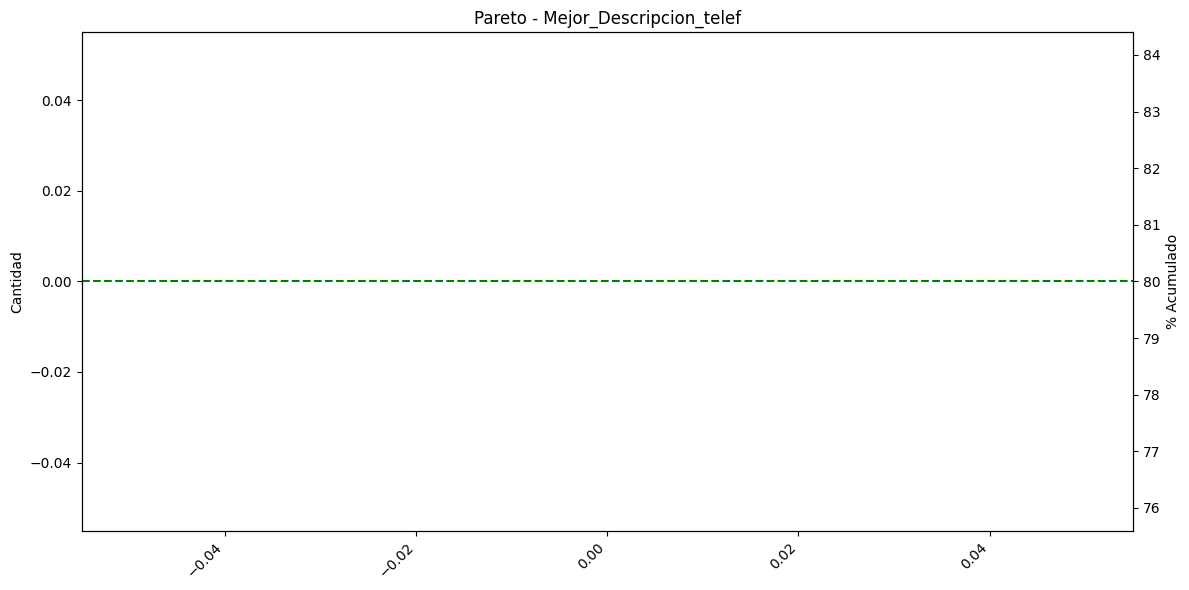

In [129]:

df_dni = df_filtrado.toPandas()
pareto_mejor_descripcion(df_dni,tipificaicon_telf)

In [48]:

exportar_lista(df_filtrado,'tc_cenco_202603301418.xlsx','linea_cencosud')

In [50]:
cantidad_leads=df_filtrado.count()

In [56]:
info_list=f"""
Se tienen {cantidad_leads} leads
Prioridad : {quintil}
maximo de intentos por num telef: {q_intentos_telef}
flg_ex_cliente :{flg_ex_cliente}
{segmento}
{first_name}

"""

print(info_list)


Se tienen 2814 leads
Prioridad : ['1', '2']
maximo de intentos por num telef: 40
flg_ex_cliente :['NUEVO']
['TC2', 'TC1']
['SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']




In [79]:
exportar_lista(df_filtrado,'tc_cencor_202603310847.xlsx','linea_cencosud')

['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'NUMERO DESCONECTADO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [ ]:
import os

ruta_archivo = os.path.join(ruta_csv, 'ivr_202603271706.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [142]:

df_dni = df_filtrado.toPandas()


In [73]:
los pu pm los qu epodemos usar


SyntaxError: invalid syntax (2290498890.py, line 1)

In [12]:

nombre_archivo_xlsx='SAE_202603251722.xlsx'
columna_ref='linea_sae'
exportar_lista(df_filtrado,nombre_archivo_xlsx,columna_ref)


In [ ]:
fecha_mes_base='2026-03-01'
t_maestra='Base_Maestra_Cencosud_PPFF'
t_name_vigente='Base_Maestra_Cencosud_PPFF_vigente'
t_mumeros='tNumeroCenco_Sae'
cols_drop=[ 'FRESCURA_TARGET', 'REP1', 'REP2', 'REP3','FLAT2']


In [97]:
df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
)
df_dni = df_filtrado.toPandas()

In [ ]:
import matplotlib.pyplot as plt

df_dni['email'].value_counts().plot(kind='bar')

plt.title('Top departamentos (email)')
plt.xlabel('Departamento')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

In [8]:
df_list.select('retiro_01').filter(col('retiro_01')==0).count()

2266

In [13]:
# print([row['first_name'] for row in df_list.select('first_name').distinct().collect()])
# print([row['title'] for row in df_list.select('title').distinct().collect()])
# print([row['tip_prioridad'] for row in df_list.select('tip_prioridad').distinct().collect()])
# print([row['email'] for row in df_list.select('email').distinct().collect()])
# print([row['prioridada'] for row in df_list.select('prioridada').distinct().collect()])
print([row['mejor15_descripcion_telf' ] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])
# print(df_list.columns)


['PERSONA FALLECIDA', 'VOLVER A LLAMAR', 'LO VA A PENSAR', 'DESEA ELECTRO', 'NEGOCIO EN ZONA NO COBERTURADA', 'TITULAR CONTAGIADO CON COVID - 19', 'CREDITO CONCRETADO', 'MENSAJES CON TERCEROS - HIJOS', 'NO DESEA SER CONTACTADO / MANIFIESTA SU RECHAZO', 'NO NECESITA / NO DESEA', 'TELEFONO APAGADO', 'NUMERO EQUIVOCADO', 'ESTA ENDEUDADO', 'MENSAJES CON TERCEROS - ESPOSA', 'OTROS', 'NO CONTESTA ', 'TITULAR NO CALIFICA- GIRO RESTRINGIDO9', 'CLIENTE RECHAZADO', 'MENSAJES CON TERCEROS - OTROS', 'NO BRINDA CONSENTIMIENTO', 'CASA EN ZONA NO COBERTURADA', 'SI QUIERE', 'CLIENTE DE VIAJE', 'TELEFONO FUERA DE SERVICIO/SUSPENDIDO', 'CONFIRMAR CITA', 'INTERESES ELEVADOS', 'NUMERO NO EXISTE', 'TITULAR NO CALIFICA - DESEMPLEO', 'MENSAJES DE TEXTO', 'TONO OCUPADO', 'SOLICITA SER RETIRADO', 'IVR - NO CONFIRMA', 'MALA EXPERIENCIA (TDA/FNC)', 'DESEA MAS MONTO', 'NO QUIERE', None]
